
CoverGuard Pipeline
=========================================================
Products:
  OPERA L3 DIST-ANN-HLS v1  — annual land surface disturbance at 30 m (COG)
  HLS L30 v2 (HLSL30)        — Landsat surface reflectance at 30 m (COG)

Usage (Google Colab):
  1. Run Cell 1 once to install dependencies.
  2. Execute remaining cells top-to-bottom.
  3. A free NASA Earthdata account is required: https://urs.earthdata.nasa.gov

Pipeline stages:
  1.  Query & download OPERA DIST-ANN layers for the AOI.
  2.  Identify "alarming" pixels via disturbance status + confidence thresholds.
  3.  Query & download HLS L30 bands for NDVI (and optionally EVI) calculation.
  4.  Apply Fmask cloud/shadow masking, then compute NDVI.
  5.  Reproject all OPERA layers onto the HLS raster grid.
  6.  Segment the scene into field-scale superpixels using SLIC.
  7.  Compute zonal NDVI and disturbance statistics per superpixel.
  8.  Flag segments by absolute NDVI and NDVI anomaly thresholds.
  9.  Score each segment 1–10 using a weighted multi-factor health model.
  10. Save GeoJSON, CSV, and a six-panel diagnostic figure.


In [ ]:
# ===========================================================================
# Cell 1 — Install dependencies (run once in Colab)
# ===========================================================================
!pip install -q earthaccess "rasterio>=1.3" "rasterstats>=0.19" \
             geopandas scikit-image matplotlib numpy pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 61.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.


In [ ]:
# ===========================================================================
# Cell 2 — Imports & configuration
# ===========================================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.features import shapes as rio_shapes
import geopandas as gpd
from shapely.geometry import shape
from shapely.ops import unary_union
from rasterstats import zonal_stats

import earthaccess

warnings.filterwarnings("ignore")

# --- Output directory ---
OUT = Path("cubesat_out")
OUT.mkdir(exist_ok=True)

# --- AOI: ~30 km × 30 km, Central Valley CA (intensively farmed) ---
# Format: (xmin, ymin, xmax, ymax) in WGS84 decimal degrees
BBOX = (-120.75, 36.50, -120.45, 36.80)

# --- Temporal windows ---
# DIST-ANN first available year is 2023 (annual calendar summaries only)
DIST_DATES = ("2023-01-01", "2023-12-31")
# Peak summer growing season for NDVI acquisition
HLS_DATES  = ("2023-06-01", "2023-08-31")

# --- Disturbance alarm thresholds ---
# VEG/GEN_DIST_STATUS: 0=none 1=first-detection 2=provisional 3=confirmed 4=ongoing
# CONF layers: 0–100 (percent confidence in detected disturbance)
VEG_STATUS_THR = 2      # ≥ provisional
VEG_CONF_THR   = 50     # ≥ 50 % confidence
GEN_STATUS_THR = 2
GEN_CONF_THR   = 50

# --- NDVI health flags ---
ALPHA_WEAK    = 0.40    # below this → "weak cover" flag
ALPHA_SEVERE  = 0.20    # below this → "severe" flag
ANOMALY_THR   = 0.15    # |segment NDVI − scene mean| → anomaly flag

# --- Grid segmentation parameter ---
# Target number of grid cells; actual cell side length l is derived at runtime
# from sqrt(H * W / GRID_N_CELLS) so the grid adapts to any BBOX size.
GRID_N_CELLS = 300

# --- Health score weights (must sum to 1.0) ---
# Each weight governs one sub-score; see compute_health_score() for details.
WEIGHTS = {
    "ndvi":        0.35,   # absolute NDVI level
    "anomaly":     0.20,   # deviation below scene mean
    "disturbance": 0.25,   # OPERA disturbance severity
    "variability": 0.10,   # within-segment patchiness
    "coverage":    0.10,   # valid-pixel fraction
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, "Weights must sum to 1.0"

In [ ]:
# ===========================================================================
# Cell 3 — Earthdata login
# ===========================================================================
# Caches credentials to ~/.netrc; prompts interactively on first Colab run.
earthaccess.login()

Enter your Earthdata Login username: architecture2
Enter your Earthdata password: ··········


In [ ]:
# ===========================================================================
# Cell 4 — Download OPERA DIST-ANN-HLS layers
# ===========================================================================
# Each of the 21 product layers is a separate COG file.
# File suffix uses dashes: e.g. _VEG-DIST-STATUS.tif, _GEN-DIST-CONF.tif

print("Searching OPERA_L3_DIST-ANN-HLS_V1 …")
dist_results = earthaccess.search_data(
    short_name="OPERA_L3_DIST-ANN-HLS_V1",
    bounding_box=BBOX,
    temporal=DIST_DATES,
    count=30,  # one MGRS tile has ~21 layer files; request generously
)
if not dist_results:
    raise RuntimeError(
        "No OPERA DIST-ANN-HLS granules found.\n"
        "  • Verify NASA Earthdata credentials.\n"
        "  • Confirm DIST_DATES is within 2023–present.\n"
        "  • Try search.earthdata.nasa.gov to check coverage for your BBOX."
    )
print(f"  Found {len(dist_results)} asset(s).")

dist_files = earthaccess.download(dist_results, local_path=str(OUT / "dist"))
print(f"  Downloaded {len(dist_files)} file(s).")

Searching OPERA_L3_DIST-ANN-HLS_V1 …
  Found 2 asset(s).


QUEUEING TASKS | :   0%|          | 0/42 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/42 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/42 [00:00<?, ?it/s]

  Downloaded 42 file(s).


In [ ]:
# ===========================================================================
# Cell 5 — Load disturbance layers
# ===========================================================================

def find_layer_file(files, keyword):
    """
    Return path of first file whose name contains `keyword`.
    Checks both dash and underscore forms since conventions vary slightly.
    """
    kd = keyword.replace("_", "-").upper()
    ku = keyword.replace("-", "_").upper()
    for f in files:
        n = Path(str(f)).name.upper()
        if kd in n or ku in n:
            return str(f)
    return None

def read_cog(fpath):
    """Read band 1 of any single-band COG; return (float32 array, profile)."""
    with rasterio.open(fpath) as src:
        return src.read(1).astype("float32"), src.profile.copy()

def load_required(files, keyword):
    """Load a mandatory disturbance layer; raise if absent."""
    f = find_layer_file(files, keyword)
    if f is None:
        raise RuntimeError(
            f"Required layer '{keyword}' not found.\n"
            "Downloaded files:\n" + "\n".join(f"  {x}" for x in files)
        )
    return read_cog(f)

def load_optional(files, keyword, shape):
    """Load an optional layer; return a zero array of matching shape if absent."""
    f = find_layer_file(files, keyword)
    if f is None:
        print(f"  Optional layer '{keyword}' not found — using zeros.")
        return np.zeros(shape, dtype="float32"), None
    return read_cog(f)

# --- Required layers ---
veg_status, d_prof = load_required(dist_files, "VEG-DIST-STATUS")
veg_conf,   _      = load_required(dist_files, "VEG-DIST-CONF")
gen_status, _      = load_required(dist_files, "GEN-DIST-STATUS")
gen_conf,   _      = load_required(dist_files, "GEN-DIST-CONF")

# --- Optional ancillary layers used in health scoring ---
# VEG-MAX-ANOM: peak spectral anomaly magnitude (0–100 scale) during disturbance
# VEG-DIST-DUR: days from first to last detected loss anomaly (duration)
veg_max_anom, _ = load_optional(dist_files, "VEG-MAX-ANOM",  veg_status.shape)
veg_dist_dur,  _ = load_optional(dist_files, "VEG-DIST-DUR",  veg_status.shape)

# --- Alarming mask (native OPERA MGRS grid) ---
# A pixel is "alarming" if vegetation OR general disturbance exceeds both thresholds.
alarming = (
    ((veg_status >= VEG_STATUS_THR) & (veg_conf >= VEG_CONF_THR)) |
    ((gen_status >= GEN_STATUS_THR) & (gen_conf >= GEN_CONF_THR))
)
print(f"Alarming pixel fraction (OPERA grid): {alarming.mean():.3%}")
if alarming.mean() == 0:
    print(
        "  WARNING: No alarming pixels found at current thresholds.\n"
        "  Consider lowering VEG_STATUS_THR or VEG_CONF_THR.\n"
        "  Continuing with full AOI for demonstration."
    )

  Optional layer 'VEG-MAX-ANOM' not found — using zeros.
Alarming pixel fraction (OPERA grid): 27.329%


In [ ]:
# ===========================================================================
# Cell 6 — Download HLS Landsat (HLSL30) for NDVI
# ===========================================================================
# HLSL30 band naming: .B02. = Blue, .B04. = Red, .B05. = NIR, .Fmask. = cloud mask

print("\nSearching HLSL30 granules …")
hls_results = earthaccess.search_data(
    short_name="HLSL30",
    bounding_box=BBOX,
    temporal=HLS_DATES,
    count=5,
)
if not hls_results:
    raise RuntimeError(
        "No HLSL30 granules found.\n"
        "  • Try widening HLS_DATES.\n"
        "  • For Sentinel-2 coverage, switch short_name to 'HLSS30' "
        "    and NIR band tag to '.B8A.'"
    )
print(f"  Found {len(hls_results)} granule(s).")

hls_files = earthaccess.download(hls_results, local_path=str(OUT / "hls"))
print(f"  Downloaded {len(hls_files)} file(s).")

def pick_band(files, tag):
    """Match an HLS file by its dot-delimited band tag (e.g. '.B04.')."""
    for f in files:
        if tag in Path(str(f)).name:
            return str(f)
    return None

blue_f  = pick_band(hls_files, ".B02.")
red_f   = pick_band(hls_files, ".B04.")
nir_f   = pick_band(hls_files, ".B05.")
fmask_f = pick_band(hls_files, ".Fmask.")

if not red_f or not nir_f:
    raise RuntimeError(
        "B04 (Red) or B05 (NIR) not found in HLSL30 download.\n"
        "Check that earthaccess downloaded individual band files, "
        "not just a granule metadata file."
    )


Searching HLSL30 granules …
  Found 5 granule(s).


QUEUEING TASKS | :   0%|          | 0/75 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/75 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/75 [00:00<?, ?it/s]

  Downloaded 75 file(s).


In [ ]:
# ===========================================================================
# Cell 7 — Compute NDVI (and EVI if blue band available) from HLS
# ===========================================================================

def read_hls_band(fpath):
    """Read HLS band, mask fill values (< 0), and return float32 array."""
    with rasterio.open(fpath) as src:
        arr = src.read(1).astype("float32")
        arr[arr < 0] = np.nan
        return arr, src.profile.copy()

red,  ndvi_profile = read_hls_band(red_f)
nir,  _            = read_hls_band(nir_f)

# HLS stores surface reflectance as scaled integers (×10 000).
# Convert to physical reflectance for EVI; NDVI ratio is scale-invariant.
scale = 10000.0 if np.nanmax(red) > 2.0 else 1.0
red_r = red / scale
nir_r = nir / scale

# --- Cloud and shadow masking using Fmask ---
# Fmask bit 1 (0x02) = cloud, bit 3 (0x08) = cloud shadow.
# A boolean cloud_mask is kept for downstream reuse even when fmask_f is absent.
cloud_mask = np.zeros_like(red, dtype=bool)
if fmask_f:
    with rasterio.open(fmask_f) as fm:
        fmask_raw = fm.read(1).astype("uint8")
    cloud_mask = ((fmask_raw & 0x02) | (fmask_raw & 0x08)) > 0
    red[cloud_mask]  = np.nan
    nir[cloud_mask]  = np.nan
    red_r[cloud_mask] = np.nan
    nir_r[cloud_mask] = np.nan

# --- NDVI ---
# np.where preserves NaN at cloud/fill pixels; np.clip alone can collapse NaN
# to the lower bound in some numpy builds.
raw_ndvi = (nir - red) / (nir + red + 1e-6)
ndvi = np.where(cloud_mask | np.isnan(raw_ndvi), np.nan,
                np.clip(raw_ndvi, -1.0, 1.0)).astype("float32")

# --- EVI (Enhanced Vegetation Index) — less saturated than NDVI at high biomass ---
# EVI = 2.5 × (NIR − Red) / (NIR + 6·Red − 7.5·Blue + 1)
evi = None
if blue_f:
    blue, _ = read_hls_band(blue_f)
    blue_r  = blue / scale
    blue_r[cloud_mask] = np.nan   # mirror the same cloud mask
    raw_evi = 2.5 * (nir_r - red_r) / (nir_r + 6 * red_r - 7.5 * blue_r + 1 + 1e-6)
    evi = np.where(cloud_mask | np.isnan(raw_evi), np.nan,
                   np.clip(raw_evi, -1.0, 2.0)).astype("float32")

# --- Save NDVI raster ---
ndvi_profile.update(dtype="float32", count=1, nodata=float("nan"))
ndvi_f = OUT / "ndvi.tif"
with rasterio.open(ndvi_f, "w", **ndvi_profile) as dst:
    dst.write(ndvi, 1)

print(
    f"NDVI  mean={np.nanmean(ndvi):.3f}  "
    f"p10={np.nanpercentile(ndvi, 10):.3f}  "
    f"p90={np.nanpercentile(ndvi, 90):.3f}"
)
if evi is not None:
    print(
        f"EVI   mean={np.nanmean(evi):.3f}  "
        f"p10={np.nanpercentile(evi, 10):.3f}  "
        f"p90={np.nanpercentile(evi, 90):.3f}"
    )

NDVI  mean=0.408  p10=0.170  p90=0.721
EVI   mean=0.295  p10=0.118  p90=0.527


In [ ]:
# ===========================================================================
# Cell 8 — Reproject all OPERA layers onto the HLS / NDVI raster grid
# ===========================================================================

with rasterio.open(ndvi_f) as src:
    ndvi_meta = src.meta.copy()
    ndvi_arr  = src.read(1)

H, W = ndvi_meta["height"], ndvi_meta["width"]

def reproj(arr, src_profile, resamp=Resampling.nearest):
    """Reproject a 2-D float32 source array into the NDVI raster grid."""
    dst = np.zeros((H, W), dtype="float32")
    reproject(
        source=arr.astype("float32"),
        destination=dst,
        src_transform=src_profile["transform"],
        src_crs=src_profile["crs"],
        dst_transform=ndvi_meta["transform"],
        dst_crs=ndvi_meta["crs"],
        resampling=resamp,
    )
    return dst

veg_status_r  = reproj(veg_status,                d_prof)
veg_conf_r    = reproj(veg_conf,                  d_prof)
gen_status_r  = reproj(gen_status,                d_prof)
gen_conf_r    = reproj(gen_conf,                  d_prof)
veg_max_anom_r = reproj(veg_max_anom,             d_prof, Resampling.bilinear)
veg_dist_dur_r = reproj(veg_dist_dur,             d_prof, Resampling.bilinear)
alarming_r     = reproj(alarming.astype("float32"), d_prof).astype(bool)



In [ ]:
# ===========================================================================
# Cell 9 — Adaptive grid segmentation
# ===========================================================================
# The scene is divided into a regular grid of l×l pixel cells.  A fixed
# target count (GRID_N_CELLS) is used to derive l from the actual raster
# dimensions, so the cell size adapts automatically to any AOI/BBOX.
#
# Cells that contain only NaN NDVI values (fully cloud-covered or fill)
# are marked with label 0 and excluded from all downstream statistics and
# health scoring — they do not contribute to the scene mean either.

GRID_N_CELLS = 300   # approximate number of grid cells across the scene

# Derive cell side length l (pixels) from the raster area.
# l = sqrt(H * W / N); rounded to nearest integer, minimum 1 pixel.
l = max(1, int(round(np.sqrt(H * W / GRID_N_CELLS))))
print(f"\nGrid cell side: {l} px  →  "
      f"{(H // l)} rows × {(W // l)} cols "
      f"= {(H // l) * (W // l)} cells (excluding boundary remainder)")

# Allocate label array; 0 = invalid/cloud-only, labels start at 1.
segments = np.zeros((H, W), dtype="int32")
label = 1
valid_cell_count = 0
cloudy_cell_count = 0

for r0 in range(0, H - l + 1, l):      # row-major iteration
    for c0 in range(0, W - l + 1, l):
        cell_ndvi = ndvi_arr[r0:r0 + l, c0:c0 + l]
        # Keep cell only if it has at least one valid (non-NaN) NDVI pixel.
        if np.any(np.isfinite(cell_ndvi)):
            segments[r0:r0 + l, c0:c0 + l] = label
            label += 1
            valid_cell_count += 1
        else:
            # Label stays 0 — cell is entirely cloud/fill; excluded downstream.
            cloudy_cell_count += 1

print(f"  Valid cells  : {valid_cell_count}")
print(f"  Cloud-only cells (excluded): {cloudy_cell_count}")


Grid cell side: 211 px  →  17 rows × 17 cols = 289 cells (excluding boundary remainder)
  Valid cells  : 185
  Cloud-only cells (excluded): 104


In [ ]:
# ===========================================================================
# Cell 10 — Convert grid cells to a GeoDataFrame
# ===========================================================================
# Each grid cell is a perfect rectangle — no fragment dissolving required.
# The alarm zone flag is computed via numpy bincount (no geometry predicates).

t   = ndvi_meta["transform"]
crs = ndvi_meta["crs"]

# --- Alarm zone flag via numpy (O(H×W), zero geometry cost) ----------------
seg_flat   = segments.ravel()
alarm_flat = alarming_r.ravel().astype(np.uint8)
n_labels   = int(segments.max()) + 1   # labels 1..n; 0 = cloud-only, ignored

alarm_px_count = np.bincount(seg_flat, weights=alarm_flat.astype(float),
                              minlength=n_labels)
alarm_by_id = alarm_px_count > 0   # True if any alarming pixel touches this cell

# --- Build one rectangular polygon per valid label -------------------------
# Rasterio's transform maps (col, row) → (x, y).  For a rectangle defined
# by pixel corners (r0, c0) to (r0+l, c0+l) in row/col space, the four
# geographic corners follow directly from the affine transform.
from rasterio.transform import xy as rio_xy
from shapely.geometry import box as shapely_box

rows_list = []
for r0 in range(0, H - l + 1, l):
    for c0 in range(0, W - l + 1, l):
        sid = int(segments[r0, c0])
        if sid == 0:
            continue   # cloud-only cell
        # Upper-left and lower-right corners in the raster's native CRS.
        x0, y0 = rio_xy(t, r0,     c0,     offset="ul")
        x1, y1 = rio_xy(t, r0 + l, c0 + l, offset="ul")
        rows_list.append({
            "seg_id":        sid,
            "geometry":      shapely_box(min(x0, x1), min(y0, y1),
                                         max(x0, x1), max(y0, y1)),
            "in_alarm_zone": bool(alarm_by_id[sid]),
        })

seg_gdf = gpd.GeoDataFrame(rows_list, crs=crs)
print(f"\nGrid GeoDataFrame: {len(seg_gdf)} valid cells.")


Grid GeoDataFrame: 185 valid cells.


In [ ]:
# ===========================================================================
# Cell 11 — Zonal statistics: NDVI and disturbance per segment
# ===========================================================================

affine = ndvi_meta["transform"]

def zs(layer, stats):
    """Shorthand for rasterstats.zonal_stats with a numpy array input."""
    return zonal_stats(seg_gdf, layer, affine=affine, stats=stats, nodata=np.nan)

ndvi_zs   = zs(ndvi_arr,       ["mean", "median", "std", "min", "max",
                                  "count", "percentile_10", "percentile_90"])
vst_zs    = zs(veg_status_r,   ["mean"])
vcf_zs    = zs(veg_conf_r,     ["mean"])
gst_zs    = zs(gen_status_r,   ["mean"])
gcf_zs    = zs(gen_conf_r,     ["mean"])
vanom_zs  = zs(veg_max_anom_r, ["mean"])
vdur_zs   = zs(veg_dist_dur_r, ["mean"])

# Add EVI zonal mean if available
if evi is not None:
    evi_zs = zs(evi, ["mean"])
    seg_gdf["evi_mean"] = [r["mean"] or 0.0 for r in evi_zs]
else:
    seg_gdf["evi_mean"] = np.nan

seg_gdf = seg_gdf.join(pd.DataFrame(ndvi_zs))

seg_gdf["veg_status_mean"]   = [r["mean"] or 0.0 for r in vst_zs]
seg_gdf["veg_conf_mean"]     = [r["mean"] or 0.0 for r in vcf_zs]
seg_gdf["gen_status_mean"]   = [r["mean"] or 0.0 for r in gst_zs]
seg_gdf["gen_conf_mean"]     = [r["mean"] or 0.0 for r in gcf_zs]
seg_gdf["veg_max_anom_mean"] = [r["mean"] or 0.0 for r in vanom_zs]
seg_gdf["veg_dist_dur_mean"] = [r["mean"] or 0.0 for r in vdur_zs]

# NDVI anomaly: segment mean minus scene mean; negative = below-average vegetation.
scene_mean = float(np.nanmean(ndvi_arr))
seg_gdf["ndvi_anomaly"] = seg_gdf["mean"].fillna(0.0) - scene_mean

# Binary disturbance and health flags
seg_gdf["flag_weak"]    = seg_gdf["mean"] < ALPHA_WEAK
seg_gdf["flag_severe"]  = seg_gdf["mean"] < ALPHA_SEVERE
seg_gdf["flag_anomaly"] = seg_gdf["ndvi_anomaly"].abs() > ANOMALY_THR



In [ ]:
# ===========================================================================
# Cell 12 — Health score (integer, 1–10)
# ===========================================================================
#
# Each segment receives five sub-scores in [0, 1]:
#
#   Sub-score     Weight  Description
#   ──────────────────────────────────────────────────────────────────────────
#   ndvi           0.35   Absolute NDVI level; linear from 0 (NDVI≤0) to 1
#                          (NDVI≥0.80). Captures current greenness.
#   anomaly        0.20   Negative departure from scene mean penalised
#                          linearly up to −0.30; positive anomalies not
#                          rewarded beyond 1.0. Captures relative stress.
#   disturbance    0.25   Disturbance status (0–4) × confidence (0–1) penalty
#                          with additional penalties for large spectral anomaly
#                          magnitude and long disturbance duration.
#   variability    0.10   High within-segment NDVI std → patchy / stressed
#                          vegetation; std ≥ 0.25 maps to 0.
#   coverage       0.10   Fraction of valid (non-NaN) pixels in the segment;
#                          cloud-covered or filled segments score low here.
#
# Composite = Σ(weight × sub-score); mapped to int ∈ [1, 10] via round(×10).

def sub_ndvi(v):
    """Map NDVI mean to [0,1]; saturates at 0.80."""
    return float(np.clip(v / 0.80, 0.0, 1.0))

def sub_anomaly(a):
    """Penalise negative anomalies; caps at −0.30 deviation."""
    return float(np.clip(1.0 - max(-a, 0.0) / 0.30, 0.0, 1.0))

def sub_disturbance(vs, vc, gs, gc, anom_mag, dur_days):
    """
    Combined disturbance sub-score.
    vs/gs : mean VEG/GEN disturbance status (0–4)
    vc/gc : mean confidence (0–100)
    anom_mag  : mean VEG-MAX-ANOM (0–100 scale)
    dur_days  : mean VEG-DIST-DUR (days)
    """
    vp   = np.clip(vs / 4.0, 0, 1) * np.clip(vc / 100.0, 0, 1)
    gp   = np.clip(gs / 4.0, 0, 1) * np.clip(gc / 100.0, 0, 1)
    base = float(np.clip(1.0 - max(vp, gp), 0.0, 1.0))
    anom_pen = float(np.clip(anom_mag / 100.0, 0.0, 0.15))  # up to 15 % extra penalty
    dur_pen  = float(np.clip(dur_days  / 365.0, 0.0, 0.10)) # up to 10 % extra penalty
    return float(np.clip(base - anom_pen - dur_pen, 0.0, 1.0))

def sub_variability(std):
    """High within-segment std → patchiness/stress; caps at 0.25."""
    return float(np.clip(1.0 - std / 0.25, 0.0, 1.0))

def sub_coverage(count, total_px):
    """Fraction of valid pixels; cloud-dominated segments penalised."""
    return float(np.clip(count / max(total_px, 1), 0.0, 1.0))

# Precompute raster pixel count per segment label
seg_px = {int(v): int((segments == v).sum()) for v in np.unique(segments)}

def compute_health_score(row):
    """Return an integer health score in [1, 10] for a single segment row."""
    ndvi_v = row["mean"]          if pd.notna(row["mean"])          else 0.0
    anom   = row["ndvi_anomaly"]  if pd.notna(row["ndvi_anomaly"])  else 0.0
    std    = row["std"]           if pd.notna(row["std"])           else 0.0
    cnt    = row["count"]         if pd.notna(row["count"])         else 0.0

    raw = (
          WEIGHTS["ndvi"]        * sub_ndvi(ndvi_v)
        + WEIGHTS["anomaly"]     * sub_anomaly(anom)
        + WEIGHTS["disturbance"] * sub_disturbance(
            row["veg_status_mean"], row["veg_conf_mean"],
            row["gen_status_mean"], row["gen_conf_mean"],
            row["veg_max_anom_mean"], row["veg_dist_dur_mean"],
          )
        + WEIGHTS["variability"] * sub_variability(std)
        + WEIGHTS["coverage"]    * sub_coverage(cnt, seg_px.get(int(row["seg_id"]), 1))
    )
    # Clamp raw to [0, 1] before scaling to guard against float accumulation,
    # then map to [1, 10] as an integer.
    return int(np.clip(round(min(raw, 1.0) * 10), 1, 10))

seg_gdf["health_score"] = seg_gdf.apply(compute_health_score, axis=1)

print("Health score distribution (1 = critically stressed, 10 = healthy):")
print(seg_gdf["health_score"].value_counts().sort_index().to_string())

Health score distribution (1 = critically stressed, 10 = healthy):
health_score
3    13
4    23
5    33
6    31
7    58
8    27


In [ ]:
# ===========================================================================
# Cell 13 — Save outputs
# ===========================================================================

keep_cols = [
    "seg_id", "in_alarm_zone",
    "mean", "median", "std", "min", "max", "percentile_10", "percentile_90",
    "evi_mean", "ndvi_anomaly",
    "flag_weak", "flag_severe", "flag_anomaly",
    "veg_status_mean", "veg_conf_mean",
    "gen_status_mean", "gen_conf_mean",
    "veg_max_anom_mean", "veg_dist_dur_mean",
    "health_score",
]

seg_gdf[keep_cols + ["geometry"]].to_crs("EPSG:4326").to_file(
    OUT / "segments.geojson", driver="GeoJSON"
)
seg_gdf[keep_cols].to_csv(OUT / "segments.csv", index=False)
print(f"Outputs written to: {OUT}/")

seg_gdf[seg_gdf[keep_cols]['health_score'] <= 3].to_csv(OUT / "segments_warning.csv", index=False)
print(f"Outputs written to: {OUT}/")


Outputs written to: cubesat_out/


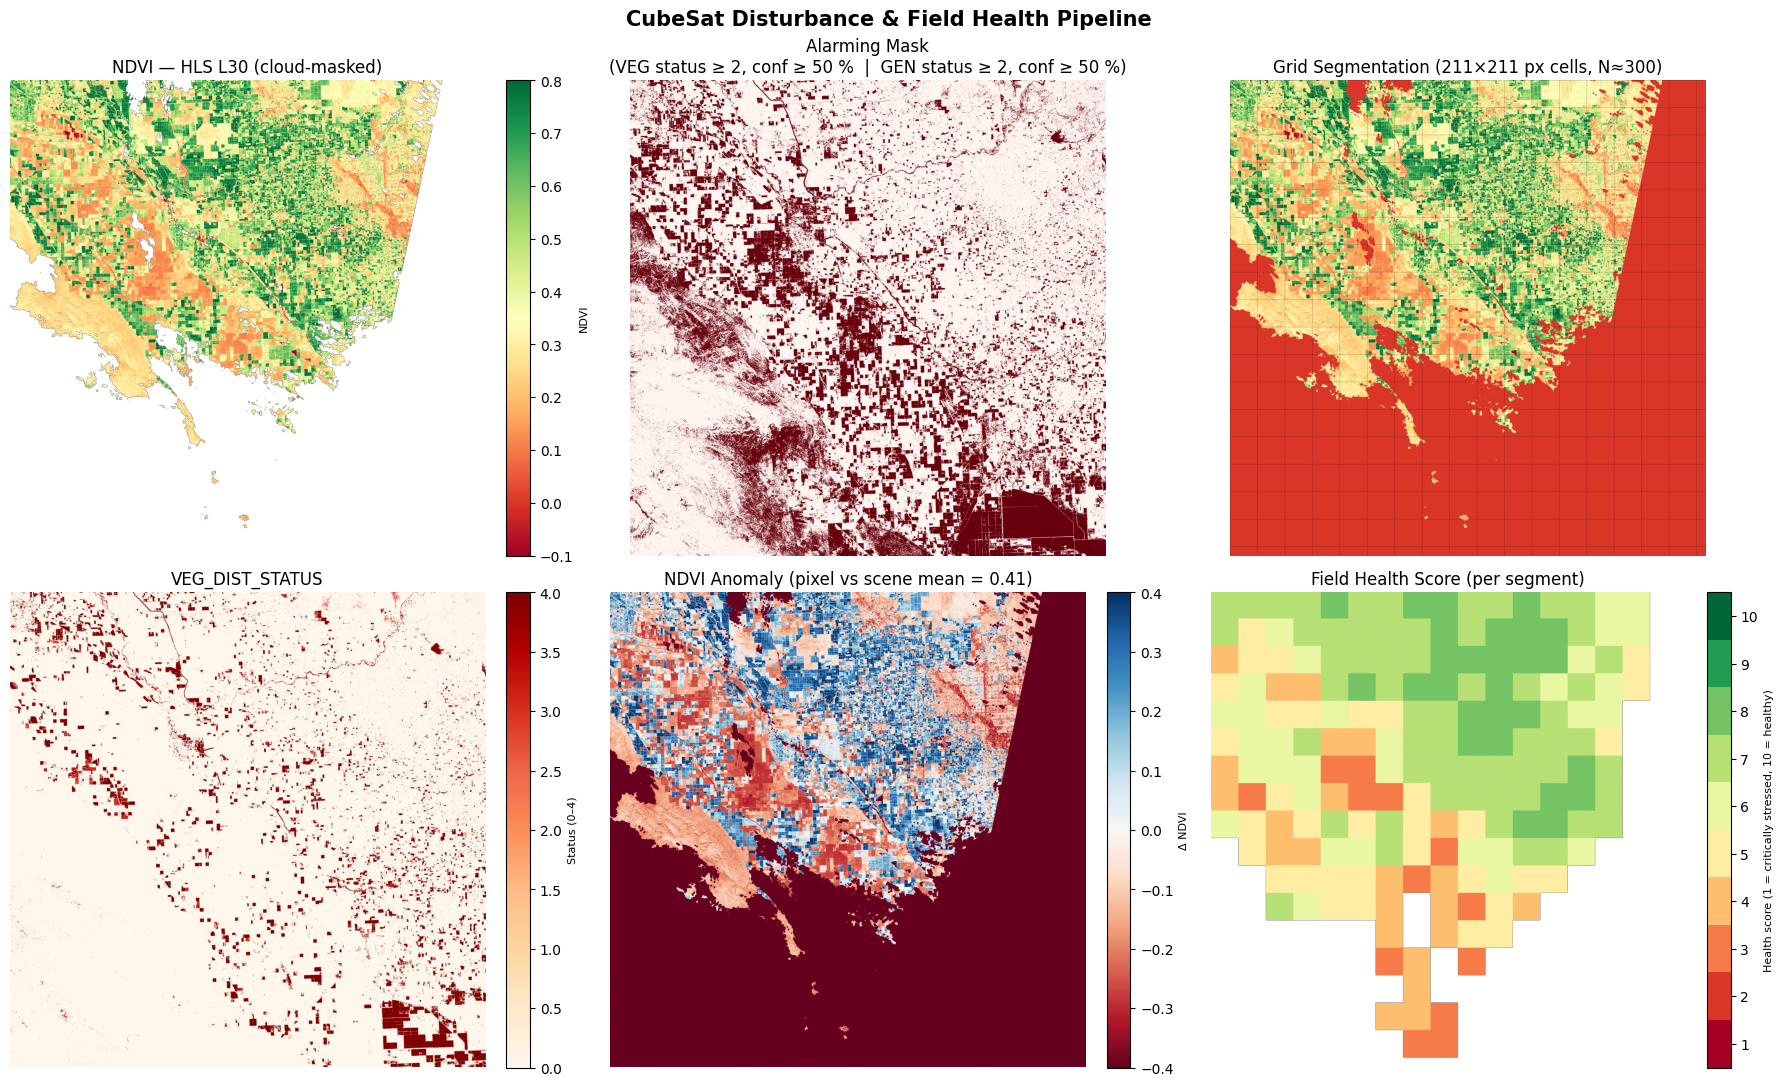

Figure saved: cubesat_out/pipeline_vis.png


In [ ]:
# ===========================================================================
# Cell 14 — Six-panel diagnostic visualisation
# ===========================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("CubeSat Disturbance & Field Health Pipeline", fontsize=15, fontweight="bold")

def add_cbar(ax, im, label):
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label(label, fontsize=8)

# Panel 1: NDVI
ax = axes[0, 0]
im = ax.imshow(ndvi_arr, cmap="RdYlGn", vmin=-0.1, vmax=0.8)
add_cbar(ax, im, "NDVI")
ax.set_title("NDVI — HLS L30 (cloud-masked)"); ax.axis("off")

# Panel 2: Alarming disturbance mask
ax = axes[0, 1]
ax.imshow(alarming_r, cmap="Reds")
ax.set_title(
    f"Alarming Mask\n"
    f"(VEG status ≥ {VEG_STATUS_THR}, conf ≥ {VEG_CONF_THR} %  |  "
    f"GEN status ≥ {GEN_STATUS_THR}, conf ≥ {GEN_CONF_THR} %)"
)
ax.axis("off")

# Panel 3: Grid cell boundaries overlaid on colour-mapped NDVI
ax = axes[0, 2]
ndvi_display = np.nan_to_num(ndvi_arr, nan=0.0)
ndvi_rgb = plt.cm.RdYlGn(plt.Normalize(-0.1, 0.8)(ndvi_display))[:, :, :3]
# Draw cell grid lines directly on the image array
grid_overlay = ndvi_rgb.copy()
for r0 in range(0, H, l):
    if r0 < H:
        grid_overlay[r0, :] = [0, 0, 0]
for c0 in range(0, W, l):
    if c0 < W:
        grid_overlay[:, c0] = [0, 0, 0]
ax.imshow(grid_overlay)
ax.set_title(f"Grid Segmentation ({l}×{l} px cells, N≈{GRID_N_CELLS})")
ax.axis("off")

# Panel 4: VEG_DIST_STATUS (reprojected to HLS grid)
ax = axes[1, 0]
im = ax.imshow(veg_status_r, cmap="OrRd", vmin=0, vmax=4)
add_cbar(ax, im, "Status (0–4)")
ax.set_title("VEG_DIST_STATUS"); ax.axis("off")

# Panel 5: Per-pixel NDVI anomaly relative to scene mean
ax = axes[1, 1]
anom_px = np.nan_to_num(ndvi_arr, nan=0.0) - scene_mean
im = ax.imshow(anom_px, cmap="RdBu", vmin=-0.4, vmax=0.4)
add_cbar(ax, im, "Δ NDVI")
ax.set_title(f"NDVI Anomaly (pixel vs scene mean = {scene_mean:.2f})"); ax.axis("off")

# Panel 6: Health score rasterised per segment
health_raster = np.full((H, W), fill_value=np.nan, dtype="float32")
for _, row in seg_gdf.iterrows():
    health_raster[segments == int(row["seg_id"])] = row["health_score"]

ax = axes[1, 2]
try:
    cmap10 = plt.colormaps["RdYlGn"].resampled(10)   # matplotlib ≥ 3.7
except AttributeError:
    cmap10 = plt.cm.get_cmap("RdYlGn", 10)           # matplotlib < 3.7
im = ax.imshow(health_raster, cmap=cmap10, vmin=0.5, vmax=10.5)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=range(1, 11))
cb.set_label("Health score (1 = critically stressed, 10 = healthy)", fontsize=8)
ax.set_title("Field Health Score (per segment)"); ax.axis("off")

plt.tight_layout()
fig_path = OUT / "pipeline_vis.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")
